In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Libraries imported successfully!")

NumPy version: 2.5.2
Pandas version: 3.0.5
Libraries imported successfully!


In [5]:
df = pd.read_csv("../data/raw/Malware dataset.csv")

In [6]:
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,cached_hole_size,free_area_cache,mm_users,map_count,hiwater_rss,total_vm,shared_vm,exec_vm,reserved_vm,nr_ptes,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0


In [8]:
df.head(10)

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,cached_hole_size,free_area_cache,mm_users,map_count,hiwater_rss,total_vm,shared_vm,exec_vm,reserved_vm,nr_ptes,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
5,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,5,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
6,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,6,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
7,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,7,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
8,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,8,malware,0,0,3069378560,14274,0,0,0,13173,0,0,24,724,6850,0,150,120,124,210,0,120,3473,341974,0,0,120,0,3204448256,380690,4,0,0,0
9,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,9,malware,0,0,3069378560,14274,0,0,0,13173,0,0,25,724,6852,0,150,120,124,211,0,120,3473,341974,0,130,120,0,3204448256,380690,4,0,0,0


In [9]:
df.tail()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,cached_hole_size,free_area_cache,mm_users,map_count,hiwater_rss,total_vm,shared_vm,exec_vm,reserved_vm,nr_ptes,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
99995,025c63d266e05d9e3bd57dd9ebd0abe904616f569fe4e2...,995,malware,4096,0,3070148608,13988,0,0,0,10406,0,0,0,616,3651,0,40,120,97,90,0,120,0,337688,2,1,120,0,3204448256,371979,3,0,0,0
99996,025c63d266e05d9e3bd57dd9ebd0abe904616f569fe4e2...,996,malware,4096,0,3070148608,13988,0,0,0,10406,0,0,0,616,3651,0,40,120,97,90,0,120,0,337688,2,1,120,0,3204448256,371979,3,0,0,0
99997,025c63d266e05d9e3bd57dd9ebd0abe904616f569fe4e2...,997,malware,4096,0,3070148608,13988,0,0,0,10406,0,0,0,616,3651,0,40,120,97,90,0,120,0,337688,2,1,120,0,3204448256,371979,3,0,0,0
99998,025c63d266e05d9e3bd57dd9ebd0abe904616f569fe4e2...,998,malware,4096,0,3070148608,13988,0,0,0,10406,0,0,0,616,3651,0,40,120,97,90,0,120,0,337688,2,1,120,0,3204448256,371979,3,0,0,0
99999,025c63d266e05d9e3bd57dd9ebd0abe904616f569fe4e2...,999,malware,4096,0,3070148608,13988,0,0,0,10406,0,0,0,616,3651,0,40,120,97,90,0,120,0,337688,2,1,120,0,3204448256,371979,3,0,0,0


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 35


In [11]:
print("Dataset shape:", df.shape)

Dataset shape: (100000, 35)


In [12]:
print(df.columns.tolist())

['hash', 'millisecond', 'classification', 'state', 'usage_counter', 'prio', 'static_prio', 'normal_prio', 'policy', 'vm_pgoff', 'vm_truncate_count', 'task_size', 'cached_hole_size', 'free_area_cache', 'mm_users', 'map_count', 'hiwater_rss', 'total_vm', 'shared_vm', 'exec_vm', 'reserved_vm', 'nr_ptes', 'end_data', 'last_interval', 'nvcsw', 'nivcsw', 'min_flt', 'maj_flt', 'fs_excl_counter', 'lock', 'utime', 'stime', 'gtime', 'cgtime', 'signal_nvcsw']


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   hash               100000 non-null  str  
 1   millisecond        100000 non-null  int64
 2   classification     100000 non-null  str  
 3   state              100000 non-null  int64
 4   usage_counter      100000 non-null  int64
 5   prio               100000 non-null  int64
 6   static_prio        100000 non-null  int64
 7   normal_prio        100000 non-null  int64
 8   policy             100000 non-null  int64
 9   vm_pgoff           100000 non-null  int64
 10  vm_truncate_count  100000 non-null  int64
 11  task_size          100000 non-null  int64
 12  cached_hole_size   100000 non-null  int64
 13  free_area_cache    100000 non-null  int64
 14  mm_users           100000 non-null  int64
 15  map_count          100000 non-null  int64
 16  hiwater_rss        100000 non-null  int64
 17  tot

In [14]:
df["classification"].value_counts()

classification
malware    50000
benign     50000
Name: count, dtype: int64

In [15]:
print(df["classification"].value_counts(normalize=True) * 100)

classification
malware    50.0
benign     50.0
Name: proportion, dtype: float64


In [16]:
df["classification"].unique()

<StringArray>
['malware', 'benign']
Length: 2, dtype: str

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   hash               100000 non-null  str  
 1   millisecond        100000 non-null  int64
 2   classification     100000 non-null  str  
 3   state              100000 non-null  int64
 4   usage_counter      100000 non-null  int64
 5   prio               100000 non-null  int64
 6   static_prio        100000 non-null  int64
 7   normal_prio        100000 non-null  int64
 8   policy             100000 non-null  int64
 9   vm_pgoff           100000 non-null  int64
 10  vm_truncate_count  100000 non-null  int64
 11  task_size          100000 non-null  int64
 12  cached_hole_size   100000 non-null  int64
 13  free_area_cache    100000 non-null  int64
 14  mm_users           100000 non-null  int64
 15  map_count          100000 non-null  int64
 16  hiwater_rss        100000 non-null  int64
 17  tot

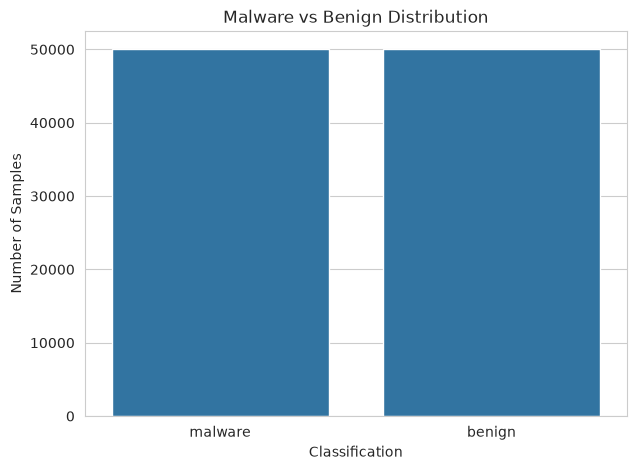

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="classification"
)

plt.title("Malware vs Benign Distribution")
plt.xlabel("Classification")
plt.ylabel("Number of Samples")

plt.show()

In [19]:
missing = df.isnull().sum()

print(missing)

hash                 0
millisecond          0
classification       0
state                0
usage_counter        0
prio                 0
static_prio          0
normal_prio          0
policy               0
vm_pgoff             0
vm_truncate_count    0
task_size            0
cached_hole_size     0
free_area_cache      0
mm_users             0
map_count            0
hiwater_rss          0
total_vm             0
shared_vm            0
exec_vm              0
reserved_vm          0
nr_ptes              0
end_data             0
last_interval        0
nvcsw                0
nivcsw               0
min_flt              0
maj_flt              0
fs_excl_counter      0
lock                 0
utime                0
stime                0
gtime                0
cgtime               0
signal_nvcsw         0
dtype: int64


In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [21]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [22]:
X = df.drop(columns=["classification"])
y = df["classification"]

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 34)
y shape: (100000,)


In [24]:
print("Hash data type:", df["hash"].dtype)
print("Unique hashes:", df["hash"].nunique())
print("Total samples:", len(df))

Hash data type: str
Unique hashes: 100
Total samples: 100000


In [25]:
X = df.drop(columns=["classification", "hash"])
y = df["classification"]

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 33)
y shape: (100000,)


In [27]:
X.describe()

,millisecond,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,cached_hole_size,free_area_cache,mm_users,map_count,hiwater_rss,total_vm,shared_vm,exec_vm,reserved_vm,nr_ptes,end_data,last_interval,nvcsw,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
count,100000.000000,1.000000e+05,100000.0,1.000000e+05,100000.000000,100000.0,100000.0,100000.0,100000.000000,100000.0,100000.0,100000.000000,100000.000000,100000.00000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.0,100000.0
mean,499.500000,1.577683e+05,0.0,3.069706e+09,18183.900070,0.0,0.0,0.0,15312.739510,0.0,0.0,9.587770,728.465430,8771.13948,0.0,266.491120,117.920240,127.678150,205.324850,0.0,117.920240,2435.973610,348313.071600,32.991160,2.053130,117.920240,1.109190,3.204448e+09,385415.451970,4.059310,1.66142,0.0,0.0
std,288.676434,9.361726e+05,0.0,2.963061e+05,4609.792765,0.0,0.0,0.0,3256.475008,0.0,0.0,46.504908,84.475361,3785.30516,0.0,311.996779,3.116892,22.277995,112.717875,0.0,3.116892,2605.564669,9117.720632,52.730176,13.881382,3.116892,2.160466,0.000000e+00,10144.036494,0.822848,3.26304,0.0,0.0
min,0.000000,0.000000e+00,0.0,3.069190e+09,13988.000000,0.0,0.0,0.0,9695.000000,0.0,0.0,0.000000,612.000000,2588.00000,0.0,4.000000,112.000000,92.000000,29.000000,0.0,112.000000,0.000000,337688.000000,0.000000,0.000000,112.000000,0.000000,3.204448e+09,371782.000000,3.000000,0.00000,0.0,0.0
25%,249.750000,0.000000e+00,0.0,3.069446e+09,14352.000000,0.0,0.0,0.0,12648.000000,0.0,0.0,0.000000,651.000000,6428.00000,0.0,99.000000,114.000000,112.000000,112.000000,0.0,114.000000,0.000000,341974.000000,1.000000,0.000000,114.000000,0.000000,3.204448e+09,378208.000000,3.000000,0.00000,0.0,0.0
50%,499.500000,0.000000e+00,0.0,3.069698e+09,16159.000000,0.0,0.0,0.0,15245.000000,0.0,0.0,1.000000,725.000000,7865.00000,0.0,177.000000,120.000000,127.000000,193.000000,0.0,120.000000,2017.000000,347244.000000,9.000000,1.000000,120.000000,0.000000,3.204448e+09,383637.000000,4.000000,0.00000,0.0,0.0
75%,749.250000,4.096000e+03,0.0,3.069957e+09,22182.000000,0.0,0.0,0.0,17663.000000,0.0,0.0,4.000000,785.000000,10684.00000,0.0,327.000000,120.000000,138.000000,273.000000,0.0,120.000000,4036.000000,351667.000000,46.000000,1.000000,120.000000,1.000000,3.204448e+09,390324.000000,5.000000,1.00000,0.0,0.0
max,999.000000,4.326605e+07,0.0,3.070222e+09,31855.000000,0.0,0.0,0.0,27157.000000,0.0,0.0,515.000000,995.000000,28184.00000,0.0,2810.000000,120.000000,196.000000,755.000000,0.0,120.000000,9526.000000,384520.000000,365.000000,256.000000,120.000000,18.000000,3.204448e+09,421913.000000,7.000000,15.00000,0.0,0.0


In [28]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
millisecond,100000.0,4.995000e+02,288.676434,0.000000e+00,2.497500e+02,4.995000e+02,7.492500e+02,9.990000e+02
state,100000.0,1.577683e+05,936172.583333,0.000000e+00,0.000000e+00,0.000000e+00,4.096000e+03,4.326605e+07
usage_counter,100000.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
prio,100000.0,3.069706e+09,296306.144183,3.069190e+09,3.069446e+09,3.069698e+09,3.069957e+09,3.070222e+09
static_prio,100000.0,1.818390e+04,4609.792765,1.398800e+04,1.435200e+04,1.615900e+04,2.218200e+04,3.185500e+04
normal_prio,100000.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
policy,100000.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
vm_pgoff,100000.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
vm_truncate_count,100000.0,1.531274e+04,3256.475008,9.695000e+03,1.264800e+04,1.524500e+04,1.766300e+04,2.715700e+04
task_size,100000.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [29]:
print(X.describe().T[["mean", "std", "min", "max"]])

                           mean            std           min           max
millisecond        4.995000e+02     288.676434  0.000000e+00  9.990000e+02
state              1.577683e+05  936172.583333  0.000000e+00  4.326605e+07
usage_counter      0.000000e+00       0.000000  0.000000e+00  0.000000e+00
prio               3.069706e+09  296306.144183  3.069190e+09  3.070222e+09
static_prio        1.818390e+04    4609.792765  1.398800e+04  3.185500e+04
normal_prio        0.000000e+00       0.000000  0.000000e+00  0.000000e+00
policy             0.000000e+00       0.000000  0.000000e+00  0.000000e+00
vm_pgoff           0.000000e+00       0.000000  0.000000e+00  0.000000e+00
vm_truncate_count  1.531274e+04    3256.475008  9.695000e+03  2.715700e+04
task_size          0.000000e+00       0.000000  0.000000e+00  0.000000e+00
cached_hole_size   0.000000e+00       0.000000  0.000000e+00  0.000000e+00
free_area_cache    9.587770e+00      46.504908  0.000000e+00  5.150000e+02
mm_users           7.2846

In [30]:
constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))
print("\nConstant features:")
print(constant_features)


Number of constant features: 11

Constant features:
['usage_counter', 'normal_prio', 'policy', 'vm_pgoff', 'task_size', 'cached_hole_size', 'hiwater_rss', 'nr_ptes', 'lock', 'cgtime', 'signal_nvcsw']


In [31]:
unique_counts = X.nunique().sort_values()

print(unique_counts)

usage_counter            1
vm_pgoff                 1
policy                   1
normal_prio              1
cached_hole_size         1
hiwater_rss              1
task_size                1
nr_ptes                  1
lock                     1
cgtime                   1
signal_nvcsw             1
shared_vm                3
maj_flt                  3
end_data                 3
stime                    5
min_flt                  5
fs_excl_counter         12
gtime                   16
last_interval           67
prio                    85
exec_vm                105
nivcsw                 150
static_prio            271
state                  304
free_area_cache        310
mm_users               373
reserved_vm            725
millisecond           1000
total_vm              1850
vm_truncate_count     2813
nvcsw                 3994
utime                 5547
map_count            10578
dtype: int64


In [32]:
infinite_count = np.isinf(X).sum().sum()

print("Total infinite values:", infinite_count)

Total infinite values: 0


In [33]:
std_values = X.std().sort_values(ascending=False)

print(std_values)

state                936172.583333
prio                 296306.144183
utime                 10144.036494
nvcsw                  9117.720632
static_prio            4609.792765
map_count              3785.305160
vm_truncate_count      3256.475008
last_interval          2605.564669
total_vm                311.996779
millisecond             288.676434
reserved_vm             112.717875
mm_users                 84.475361
nivcsw                   52.730176
free_area_cache          46.504908
exec_vm                  22.277995
min_flt                  13.881382
gtime                     3.263040
maj_flt                   3.116892
end_data                  3.116892
shared_vm                 3.116892
fs_excl_counter           2.160466
stime                     0.822848
usage_counter             0.000000
policy                    0.000000
normal_prio               0.000000
hiwater_rss               0.000000
task_size                 0.000000
cached_hole_size          0.000000
vm_pgoff            

In [34]:
comparison = df.groupby("classification")[X.columns].mean().T

print(comparison)

classification           benign       malware
millisecond        4.995000e+02  4.995000e+02
state              2.183401e+05  9.719661e+04
usage_counter      0.000000e+00  0.000000e+00
prio               3.069673e+09  3.069739e+09
static_prio        1.964953e+04  1.671827e+04
normal_prio        0.000000e+00  0.000000e+00
policy             0.000000e+00  0.000000e+00
vm_pgoff           0.000000e+00  0.000000e+00
vm_truncate_count  1.646833e+04  1.415715e+04
task_size          0.000000e+00  0.000000e+00
cached_hole_size   0.000000e+00  0.000000e+00
free_area_cache    1.197052e+01  7.205020e+00
mm_users           7.363757e+02  7.205551e+02
map_count          9.797813e+03  7.744466e+03
hiwater_rss        0.000000e+00  0.000000e+00
total_vm           2.849897e+02  2.479926e+02
shared_vm          1.189331e+02  1.169074e+02
exec_vm            1.333618e+02  1.219945e+02
reserved_vm        2.186940e+02  1.919557e+02
nr_ptes            0.000000e+00  0.000000e+00
end_data           1.189331e+02  1

In [35]:
comparison["difference"] = (
    comparison["malware"] -
    comparison["benign"]
)

comparison = comparison.sort_values(
    "difference",
    key=abs,
    ascending=False
)

comparison.head(15)


classification,benign,malware,difference
state,2.183401e+05,9.719661e+04,-121143.45984
prio,3.069673e+09,3.069739e+09,65208.32000
utime,3.891680e+05,3.816629e+05,-7505.14810
nvcsw,3.518406e+05,3.447855e+05,-7055.06200
static_prio,1.964953e+04,1.671827e+04,-2931.26622
vm_truncate_count,1.646833e+04,1.415715e+04,-2311.17818
map_count,9.797813e+03,7.744466e+03,-2053.34648
total_vm,2.849897e+02,2.479926e+02,-36.99708
last_interval,2.417860e+03,2.454088e+03,36.22778
reserved_vm,2.186940e+02,1.919557e+02,-26.73830


In [36]:
non_constant_features = [
    col for col in X.columns
    if col not in constant_features
]

features_to_plot = non_constant_features[:4]

print(features_to_plot)

['millisecond', 'state', 'prio', 'static_prio']


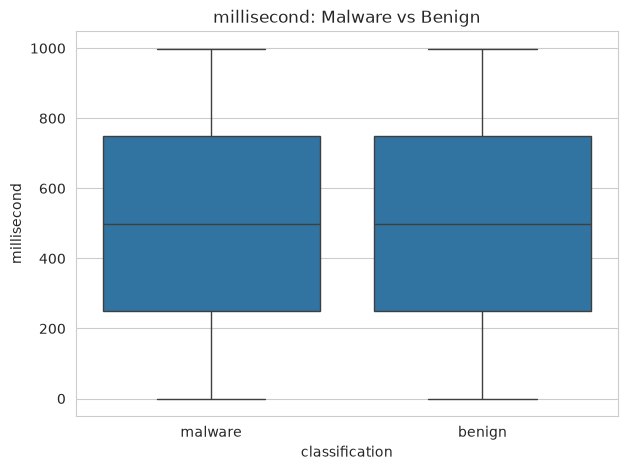

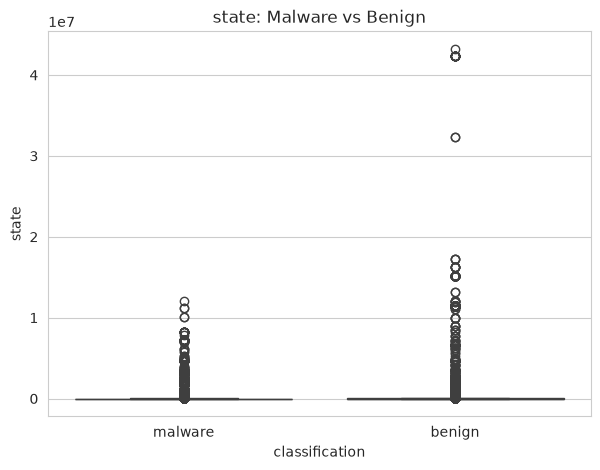

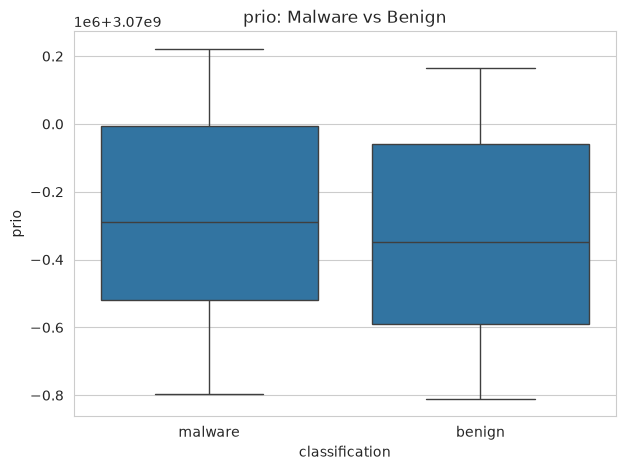

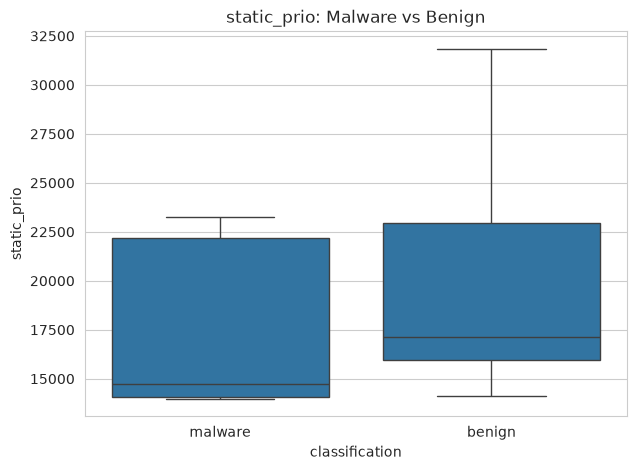

In [37]:
for feature in features_to_plot:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="classification",
        y=feature
    )

    plt.title(
        f"{feature}: Malware vs Benign"
    )

    plt.show()

In [38]:
X_non_constant = X.drop(
    columns=constant_features
)

correlation = X_non_constant.corr()

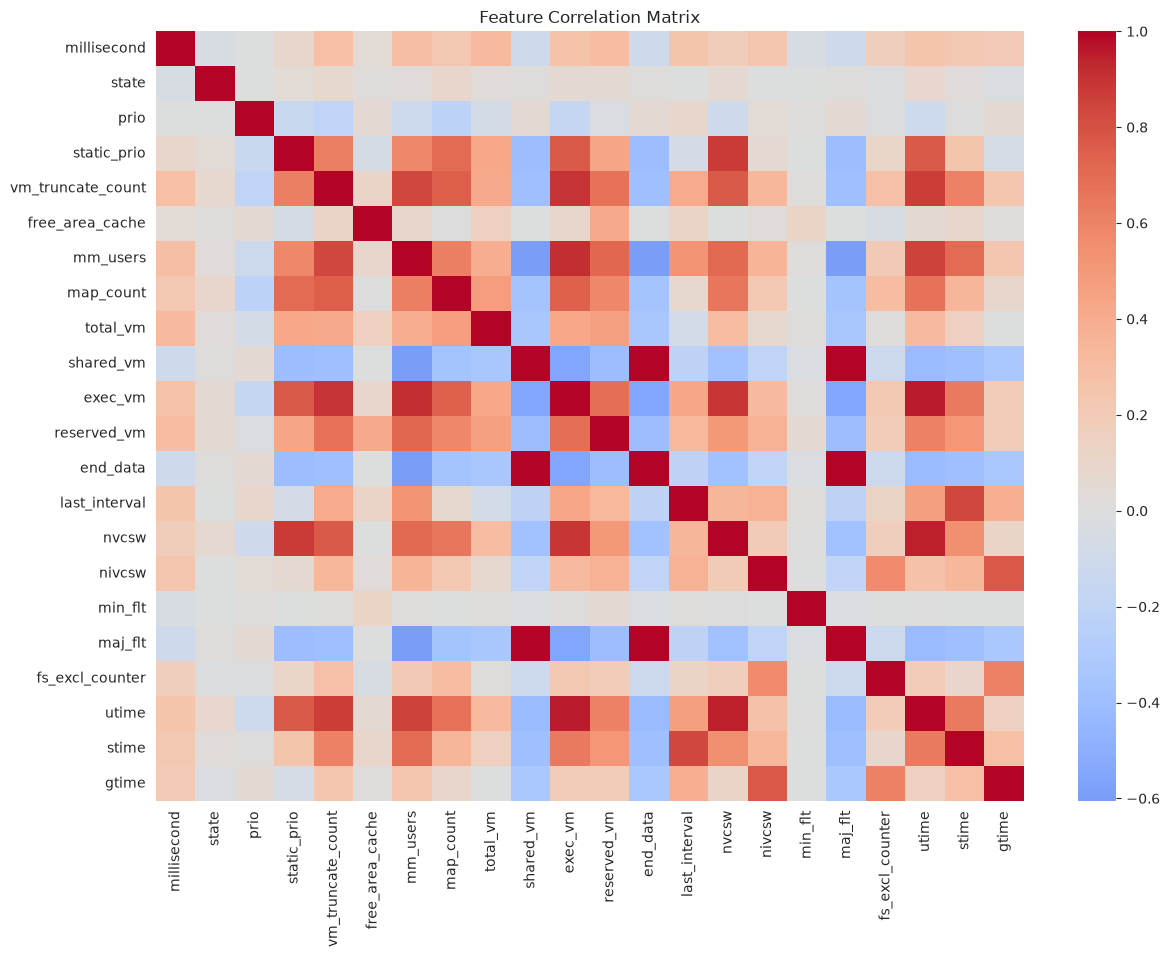

In [39]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [40]:
corr_matrix = X_non_constant.corr()

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(15))

end_data           maj_flt     1.000000
shared_vm          maj_flt     1.000000
                   end_data    1.000000
exec_vm            utime       0.955050
nvcsw              utime       0.946083
mm_users           exec_vm     0.917771
vm_truncate_count  exec_vm     0.901101
exec_vm            nvcsw       0.888427
static_prio        nvcsw       0.874921
vm_truncate_count  utime       0.864216
mm_users           utime       0.850822
vm_truncate_count  mm_users    0.837655
last_interval      stime       0.834799
nivcsw             gtime       0.780421
static_prio        utime       0.773214
dtype: float64


In [41]:
strong_correlations = corr_pairs[
    abs(corr_pairs) >= 0.80
]

print(strong_correlations)

end_data           maj_flt     1.000000
shared_vm          maj_flt     1.000000
                   end_data    1.000000
exec_vm            utime       0.955050
nvcsw              utime       0.946083
mm_users           exec_vm     0.917771
vm_truncate_count  exec_vm     0.901101
exec_vm            nvcsw       0.888427
static_prio        nvcsw       0.874921
vm_truncate_count  utime       0.864216
mm_users           utime       0.850822
vm_truncate_count  mm_users    0.837655
last_interval      stime       0.834799
dtype: float64


In [42]:
comparison = df.groupby("classification")[X_non_constant.columns].mean().T

comparison["difference"] = (
    comparison["malware"] -
    comparison["benign"]
)

comparison = comparison.sort_values(
    "difference",
    key=abs,
    ascending=False
)

comparison.head(15)

classification,benign,malware,difference
state,2.183401e+05,9.719661e+04,-121143.45984
prio,3.069673e+09,3.069739e+09,65208.32000
utime,3.891680e+05,3.816629e+05,-7505.14810
nvcsw,3.518406e+05,3.447855e+05,-7055.06200
static_prio,1.964953e+04,1.671827e+04,-2931.26622
vm_truncate_count,1.646833e+04,1.415715e+04,-2311.17818
map_count,9.797813e+03,7.744466e+03,-2053.34648
total_vm,2.849897e+02,2.479926e+02,-36.99708
last_interval,2.417860e+03,2.454088e+03,36.22778
reserved_vm,2.186940e+02,1.919557e+02,-26.73830


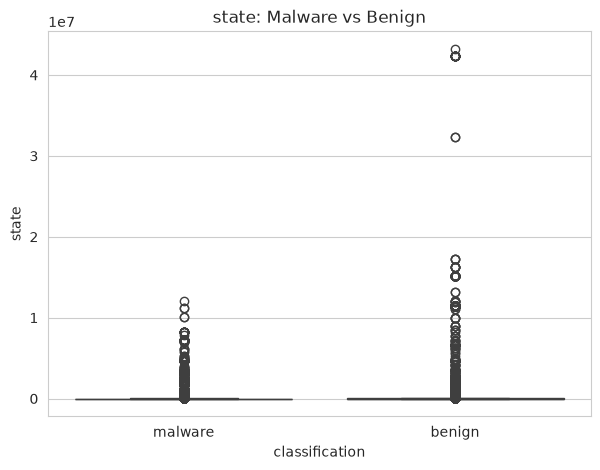

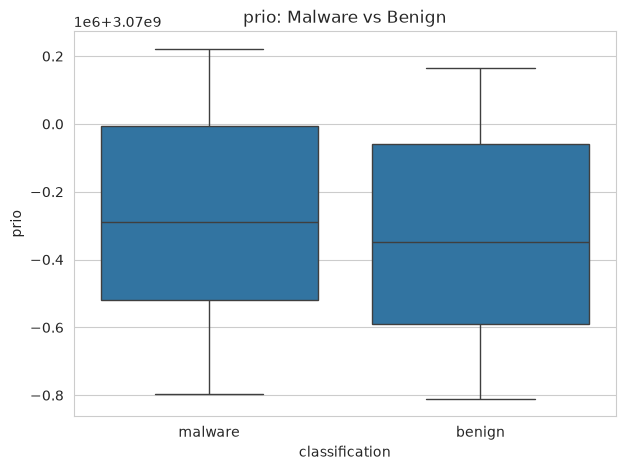

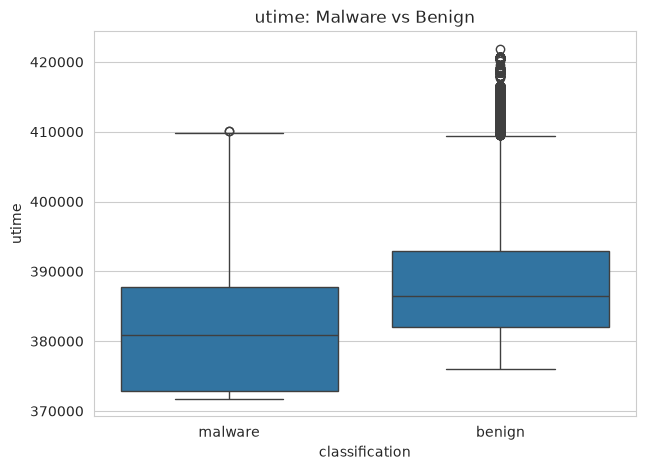

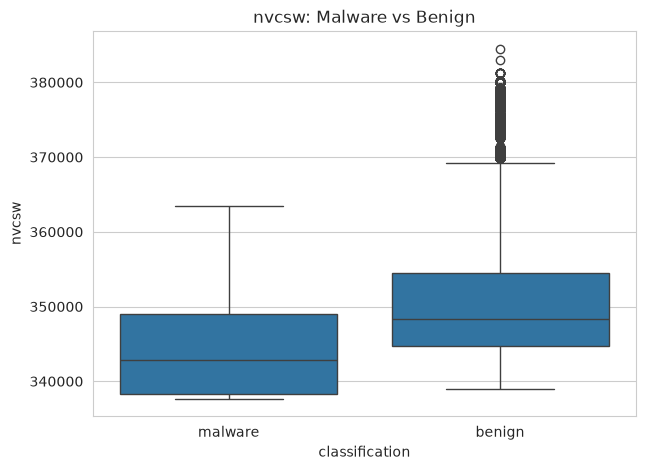

In [43]:
top_features = comparison.head(4).index

for feature in top_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="classification",
        y=feature
    )

    plt.title(f"{feature}: Malware vs Benign")
    plt.show()

In [44]:
Q1 = X_non_constant.quantile(0.25)
Q3 = X_non_constant.quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    ((X_non_constant < (Q1 - 1.5 * IQR)) |
     (X_non_constant > (Q3 + 1.5 * IQR)))
    .sum()
    .sort_values(ascending=False)
)

print(outlier_counts)

state                20177
gtime                18745
free_area_cache      14854
fs_excl_counter      13590
nivcsw                9789
nvcsw                 6545
total_vm              5759
utime                 3770
map_count             2517
exec_vm               1587
reserved_vm           1413
min_flt                991
vm_truncate_count      283
mm_users               173
prio                     0
static_prio              0
millisecond              0
shared_vm                0
last_interval            0
end_data                 0
maj_flt                  0
stime                    0
dtype: int64


In [45]:
top_outlier_features = outlier_counts.head(5)

print(top_outlier_features)

state              20177
gtime              18745
free_area_cache    14854
fs_excl_counter    13590
nivcsw              9789
dtype: int64


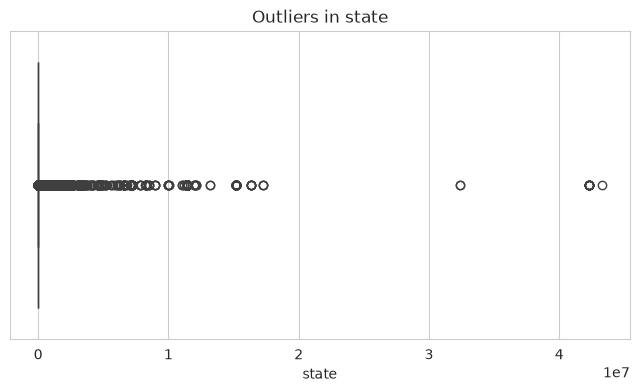

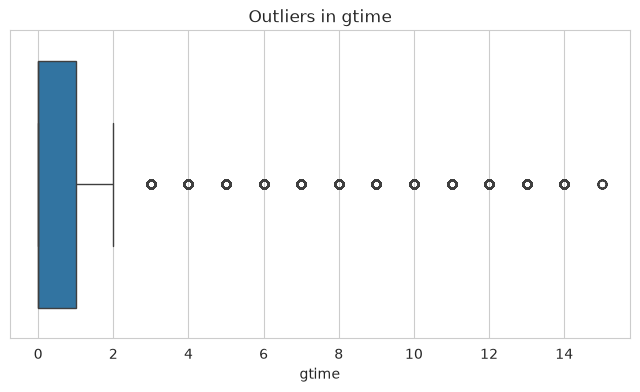

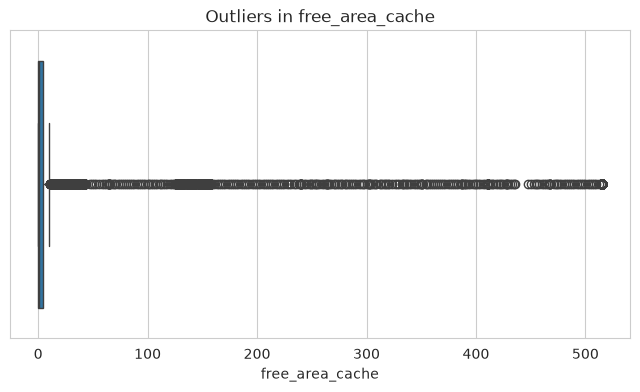

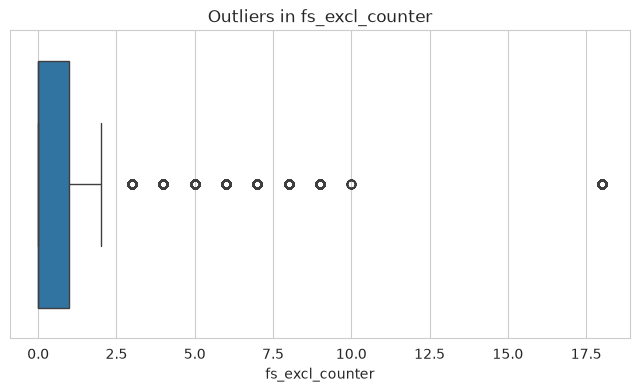

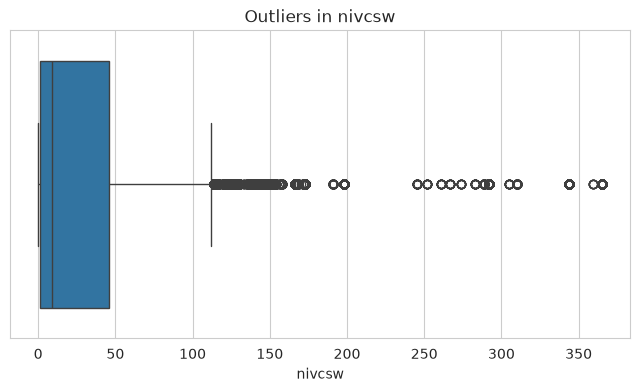

In [46]:
for feature in top_outlier_features.index:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Outliers in {feature}")

    plt.show()

In [47]:
df_clean = df.copy()

In [48]:
df_clean = df_clean.drop(columns=["hash"])

In [49]:
df_clean = df_clean.drop(columns=constant_features)

In [50]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (100000, 35)
Cleaned shape: (100000, 23)


In [51]:
X = df_clean.drop(columns=["classification"])
y = df_clean["classification"]

In [52]:
print("X:", X.shape)
print("y:", y.shape)

X: (100000, 22)
y: (100000,)


In [53]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [54]:
print(label_encoder.classes_)
print(np.unique(y, return_counts=True))

['benign' 'malware']
(array([0, 1]), array([50000, 50000]))


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80000, 22)
Testing: (20000, 22)


In [57]:
from sklearn.preprocessing import LabelEncoder

In [58]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [59]:
print("Classes:", label_encoder.classes_)

Classes: [0 1]


In [60]:
print("Encoded target distribution:")
print(np.unique(y, return_counts=True))

Encoded target distribution:
(array([0, 1]), array([50000, 50000]))


In [61]:
print("Training distribution:")
print(np.unique(y_train, return_counts=True))

print("\nTesting distribution:")
print(np.unique(y_test, return_counts=True))

Training distribution:
(array([0, 1]), array([40000, 40000]))

Testing distribution:
(array([0, 1]), array([10000, 10000]))


In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [64]:
baseline_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [65]:
y_pred_baseline = baseline_model.predict(X_test)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)

print("Logistic Regression Baseline")
print("----------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Logistic Regression Baseline
----------------------------
Accuracy : 0.7400
Precision: 0.6989
Recall   : 0.8434
F1-score : 0.7644


In [68]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_baseline,
        labels=[0, 1],
        target_names=["benign", "malware"]
    )
)

              precision    recall  f1-score   support

      benign       0.80      0.64      0.71     10000
     malware       0.70      0.84      0.76     10000

    accuracy                           0.74     20000
   macro avg       0.75      0.74      0.74     20000
weighted avg       0.75      0.74      0.74     20000



In [69]:
from sklearn.metrics import roc_auc_score

y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_proba_baseline
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8115


In [70]:
import joblib

joblib.dump(
    baseline_model,
    "../ml/models/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [71]:
joblib.dump(
    label_encoder,
    "../ml/models/label_encoder.pkl"
)

['../ml/models/label_encoder.pkl']

In [72]:
loaded_model = joblib.load(
    "../ml/models/logistic_regression.pkl"
)

loaded_encoder = joblib.load(
    "../ml/models/label_encoder.pkl"
)

print("Models loaded successfully!")

Models loaded successfully!


In [73]:
test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Encoded predictions:", test_prediction)
print(
    "Decoded predictions:",
    loaded_encoder.inverse_transform(test_prediction)
)

Encoded predictions: [1 0 0 1 0]
Decoded predictions: [1 0 0 1 0]


In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
print(RandomForestClassifier)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [76]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [77]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [78]:
y_pred_rf = rf_model.predict(X_test)

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [80]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

y_proba_rf = rf_model.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Results")
print("----------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Results
----------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000


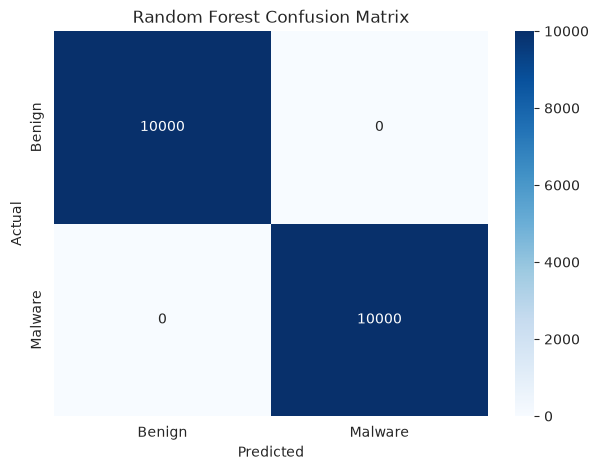

In [81]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malware"],
    yticklabels=["Benign","Malware"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [82]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,static_prio,0.230069
5,free_area_cache,0.103672
19,utime,0.095819
14,nvcsw,0.094971
10,exec_vm,0.053334
12,end_data,0.050738
4,vm_truncate_count,0.049520
17,maj_flt,0.049058
9,shared_vm,0.042616
7,map_count,0.037044


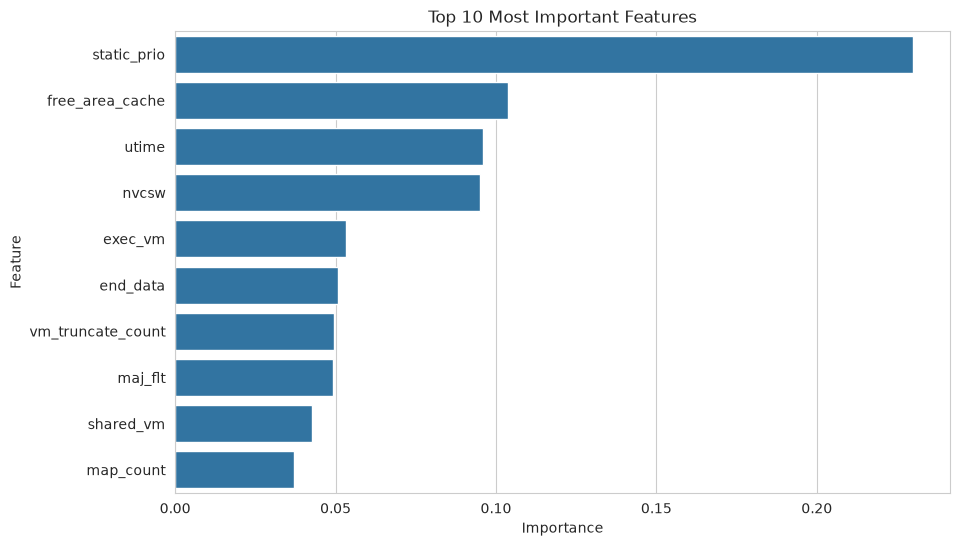

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

In [84]:
import joblib

joblib.dump(rf_model, "../ml/models/random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [85]:
hash_class_distribution = (
    df.groupby("hash")["classification"]
      .nunique()
)

print(hash_class_distribution.value_counts())

classification
1    100
Name: count, dtype: int64


In [86]:
from sklearn.model_selection import GroupShuffleSplit

In [87]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df_clean,
        y,
        groups=df["hash"]
    )
)

In [88]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=df["hash"]
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (80000, 22)
Testing : (20000, 22)


In [89]:
train_hashes = set(df["hash"].iloc[train_idx])
test_hashes = set(df["hash"].iloc[test_idx])

print("Training hashes:", len(train_hashes))
print("Testing hashes:", len(test_hashes))
print("Common hashes:", len(train_hashes & test_hashes))

Training hashes: 80
Testing hashes: 20
Common hashes: 0


In [90]:
print("Training distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts())

Training distribution:
0    42000
1    38000
Name: count, dtype: int64

Testing distribution:
1    12000
0     8000
Name: count, dtype: int64


In [91]:
print("Common hashes:",
      len(set(df["hash"].iloc[train_idx]) &
          set(df["hash"].iloc[test_idx])))

Common hashes: 0


In [92]:
print(
    df.groupby("classification")["hash"].nunique()
)

classification
benign     50
malware    50
Name: hash, dtype: int64


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model_grouped = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [94]:
rf_model_grouped.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [95]:
y_pred_rf = rf_model_grouped.predict(X_test)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

y_proba_rf = rf_model_grouped.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest — Group-Aware Evaluation")
print("----------------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest — Group-Aware Evaluation
----------------------------------------
Accuracy : 0.8952
Precision: 0.8514
Recall   : 1.0000
F1-score : 0.9197
ROC-AUC  : 0.9976


In [97]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[ 5905  2095]
 [    0 12000]]


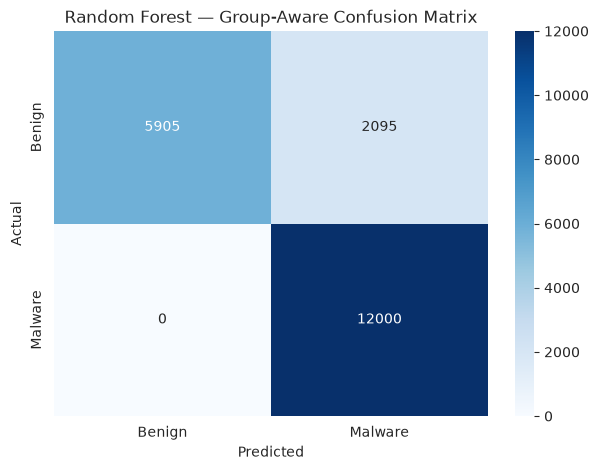

In [98]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)

plt.title("Random Forest — Group-Aware Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [99]:
import joblib

joblib.dump(
    rf_model_grouped,
    "../ml/models/random_forest.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [100]:
import os

print(os.path.exists("../ml/models/random_forest.pkl"))

True


In [101]:
loaded_rf = joblib.load("../ml/models/random_forest.pkl")

print("Random Forest loaded successfully!")

Random Forest loaded successfully!


In [102]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:
from xgboost import XGBClassifier

In [104]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [105]:
X_train
X_test
y_train
y_test

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,))

In [106]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [107]:
y_pred_xgb = xgb_model.predict(X_test)

In [108]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.9426
Precision: 0.9127
Recall   : 1.0000
F1-score : 0.9544
ROC-AUC  : 0.9885


In [110]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[ 6852  1148]
 [    0 12000]]


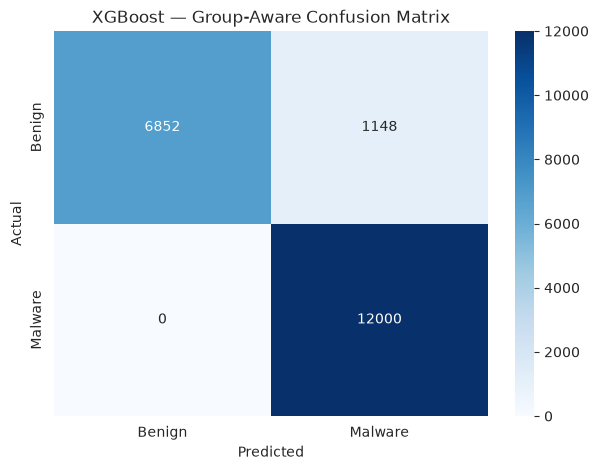

In [111]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)

plt.title("XGBoost — Group-Aware Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [113]:
import joblib

joblib.dump(
    xgb_model,
    "../ml/models/xgboost.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!
